# Lab 2 Worksheet - Feature Engineering, Outlier Treatment, Scaling, Visualization & ML Readiness

## Learning Outcomes
- Feature Engineering
- Detect outliers using IQR and Z-Score.
- Treat outliers using Winsorization (capping).
- Apply StandardScaler, MinMaxScaler, RobustScaler, and MaxAbsScaler.
- Compare preprocessing results using visualizations.
- Prepare an ML-ready dataset using train/test split.


# D. Feature Engineering

This notebook introduces common feature engineering techniques used to improve machine learning models.

In [ ]:
import pandas as pd
import numpy as np
import gdown

file_id = "1t5mmVocO1_fGXGqRftpekRom9yxq-ML4"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "student_clean_dataset.csv",
    quiet=False
)

df = pd.read_csv("student_clean_dataset.csv")

df

Downloading...
From: https://drive.google.com/uc?id=1t5mmVocO1_fGXGqRftpekRom9yxq-ML4
To: /content/student_clean_dataset.csv
100%|██████████| 19.1k/19.1k [00:00<00:00, 32.5MB/s]


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18,Male,Computer Science,3,98,12,60,Pass,B,Not Placed,0.00
1,ST002,20,Male,Computer Science,1,81,11,44,Pass,D,Not Placed,0.00
2,ST003,19,Male,Computer Science,3,76,9,46,Pass,D,Not Placed,0.00
3,ST004,19,Female,Computer Science,5,100,10,51,Pass,C,Placed,3.39
4,ST005,18,Female,Computer Science,5,68,13,54,Pass,C,Placed,3.12
...,...,...,...,...,...,...,...,...,...,...,...,...
295,ST296,18,Male,Computer Science,8,86,16,74,Pass,A,Not Placed,0.00
296,ST297,19,Female,Computer Science,9,80,19,92,Pass,A+,Placed,19.43
297,ST298,18,Male,Mechanical,9,81,20,94,Pass,A+,Placed,14.97
298,ST299,19,Male,Computer Science,6,82,18,82,Pass,A+,Placed,7.40



## 1. Create Derived Features


In [ ]:
df["Total_Effort"] = df["Study_Hours"] + df["Assignments"]
df["Performance_Index"] = (
    df["Exam_Score"] * df["Attendance"] / 100
).round(2)

df[["Study_Hours","Assignments","Total_Effort","Performance_Index"]]


,Study_Hours,Assignments,Total_Effort,Performance_Index
0,3,12,15,58.80
1,1,11,12,35.64
2,3,9,12,34.96
3,5,10,15,51.00
4,5,13,18,36.72
...,...,...,...,...
295,8,16,24,63.64
296,9,19,28,73.60
297,9,20,29,76.14
298,6,18,24,67.24



## 2. Create Ratio Features


In [ ]:
df["Score_per_Study_Hour"] = (
    df["Exam_Score"] / df["Study_Hours"]
).round(2)

df[["Exam_Score","Study_Hours","Score_per_Study_Hour"]]


,Exam_Score,Study_Hours,Score_per_Study_Hour
0,60,3,20.00
1,44,1,44.00
2,46,3,15.33
3,51,5,10.20
4,54,5,10.80
...,...,...,...
295,74,8,9.25
296,92,9,10.22
297,94,9,10.44
298,82,6,13.67



## 3. Create Bins using pd.cut()

In [ ]:
df["Attendance_Level"] = pd.cut(
    df["Attendance"],
    bins=[0,70,85,100],
    labels=["Low","Medium","High"]
)

df[["Attendance","Attendance_Level"]]


,Attendance,Attendance_Level
0,98,High
1,81,Medium
2,76,Medium
3,100,High
4,68,Low
...,...,...
295,86,High
296,80,Medium
297,81,Medium
298,82,Medium



## 4. Map Categories to Numerical Values


In [ ]:
df["Gender_Code"] = df["Gender"].map({
    "Male":0,
    "Female":1
})

dept_map = {
    "Computer Science":1,
    "Information Technology":2,
    "Electronics":3,
    "Mechanical":4
}

df["Department_Code"] = df["Department"].map(dept_map)

df[["Gender","Gender_Code","Department","Department_Code"]]


,Gender,Gender_Code,Department,Department_Code
0,Male,0,Computer Science,1
1,Male,0,Computer Science,1
2,Male,0,Computer Science,1
3,Female,1,Computer Science,1
4,Female,1,Computer Science,1
...,...,...,...,...
295,Male,0,Computer Science,1
296,Female,1,Computer Science,1
297,Male,0,Mechanical,4
298,Male,0,Computer Science,1



## 5. Remove Irrelevant / Identifier Columns


In [ ]:
feature_df = df.copy()

feature_df.drop(columns=["Student_ID"], inplace=True)

feature_df.head()


,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA,Total_Effort,Performance_Index,Score_per_Study_Hour,Attendance_Level,Gender_Code,Department_Code
0,18,Male,Computer Science,3,98,12,60,Pass,B,Not Placed,0.00,15,58.80,20.00,High,0,1
1,20,Male,Computer Science,1,81,11,44,Pass,D,Not Placed,0.00,12,35.64,44.00,Medium,0,1
2,19,Male,Computer Science,3,76,9,46,Pass,D,Not Placed,0.00,12,34.96,15.33,Medium,0,1
3,19,Female,Computer Science,5,100,10,51,Pass,C,Placed,3.39,15,51.00,10.20,High,1,1
4,18,Female,Computer Science,5,68,13,54,Pass,C,Placed,3.12,18,36.72,10.80,Low,1,1



# E. Categorical Data Processing

This notebook demonstrates how to process categorical variables for machine learning using Label Encoding and One-Hot Encoding.


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df = pd.DataFrame({
    "Student_ID":[101,102,103,104,105,106,107,108],
    "Department":["CSE","ECE","Civil","Mechanical","CSE","ECE","Civil","Mechanical"],
    "Grade":["Poor","Average","Good","Excellent","Good","Average","Excellent","Poor"],
    "Gender":["Male","Female","Female","Male","Female","Male","Female","Male"],
    "Placement":["Yes","No","Yes","Yes","No","Yes","No","Yes"]
})

df


,Student_ID,Department,Grade,Gender,Placement
0,101,CSE,Poor,Male,Yes
1,102,ECE,Average,Female,No
2,103,Civil,Good,Female,Yes
3,104,Mechanical,Excellent,Male,Yes
4,105,CSE,Good,Female,No
5,106,ECE,Average,Male,Yes
6,107,Civil,Excellent,Female,No
7,108,Mechanical,Poor,Male,Yes



## 1. Nominal vs Ordinal Features

- **Nominal:** Department, Gender (no natural ordering)
- **Ordinal:** Grade (Poor < Average < Good < Excellent)

## 2. Label Encoding (Ordinal Feature)


In [ ]:
grade_mapping = {
    "Poor":0,
    "Average":1,
    "Good":2,
    "Excellent":3
}

manual_df = df.copy()
manual_df["Grade_Code"] = manual_df["Grade"].map(grade_mapping)

manual_df[["Grade","Grade_Code"]]


,Grade,Grade_Code
0,Poor,0
1,Average,1
2,Good,2
3,Excellent,3
4,Good,2
5,Average,1
6,Excellent,3
7,Poor,0



### Using LabelEncoder()


In [ ]:
le = LabelEncoder()

label_df = df.copy()
label_df["Placement_Code"] = le.fit_transform(label_df["Placement"])

label_df[["Placement","Placement_Code"]]


,Placement,Placement_Code
0,Yes,1
1,No,0
2,Yes,1
3,Yes,1
4,No,0
5,Yes,1
6,No,0
7,Yes,1



## 3. One-Hot Encoding using pandas


In [ ]:
dummy_df = pd.get_dummies(
    df,
    columns=["Department","Gender"],
    drop_first=True
)

dummy_df.head()


,Student_ID,Grade,Placement,Department_Civil,Department_ECE,Department_Mechanical,Gender_Male
0,101,Poor,Yes,False,False,False,True
1,102,Average,No,False,True,False,False
2,103,Good,Yes,True,False,False,False
3,104,Excellent,Yes,False,False,True,True
4,105,Good,No,False,False,False,False



## 4. One-Hot Encoding using Scikit-Learn


In [ ]:
encoder = OneHotEncoder(drop="first", sparse_output=False)

encoded = encoder.fit_transform(df[["Department"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["Department"])
)

encoded_df


,Department_Civil,Department_ECE,Department_Mechanical
0,0.0,0.0,0.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,0.0,0.0,0.0
5,0.0,1.0,0.0
6,1.0,0.0,0.0
7,0.0,0.0,1.0


#F. Detecting outliers using IQR and Z-Score.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import train_test_split

plt.rcParams["figure.figsize"]=(8,4)
sns.set_style("whitegrid")


## 1. Load Dataset

In [ ]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Visualize Outliers

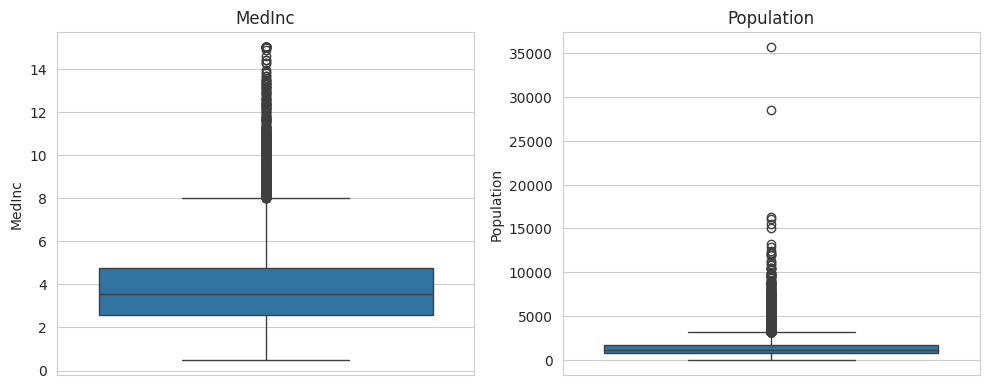

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.boxplot(y=df["MedInc"],ax=ax[0]); ax[0].set_title("MedInc")
sns.boxplot(y=df["Population"],ax=ax[1]); ax[1].set_title("Population")
plt.tight_layout()

## 3. Detect Outliers using IQR

In [ ]:
Q1=df["MedInc"].quantile(0.25)
Q3=df["MedInc"].quantile(0.75)
IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers_iqr=df[(df["MedInc"]<lower)|(df["MedInc"]>upper)]

print("Lower Bound:",lower)
print("Upper Bound:",upper)
print("IQR Outliers:",len(outliers_iqr))

Lower Bound: -0.7063750000000004
Upper Bound: 8.013024999999999
IQR Outliers: 681


## 4. Detect Outliers using Z-Score
z = ( x - μ ) / σ

In [ ]:
z_scores=zscore(df["MedInc"])
outliers_z=df[np.abs(z_scores)>3]
print("Z-Score Outliers:",len(outliers_z))

Z-Score Outliers: 345


## 5. Treat Outliers (Winsorization/Capping)

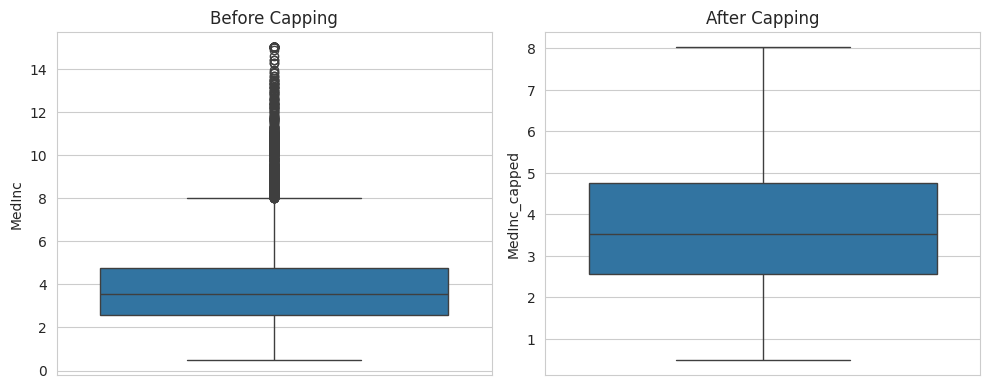

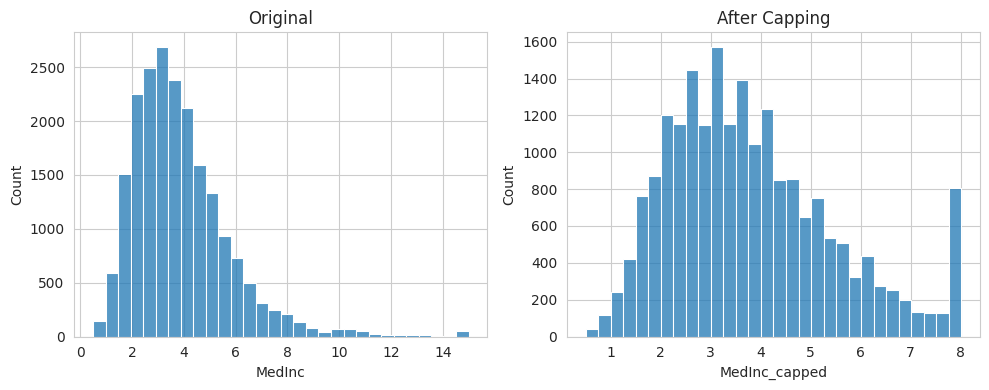

In [ ]:
df["MedInc_capped"]=df["MedInc"].clip(lower,upper)

fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.boxplot(y=df["MedInc"],ax=ax[0]); ax[0].set_title("Before Capping")
sns.boxplot(y=df["MedInc_capped"],ax=ax[1]); ax[1].set_title("After Capping")
plt.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.histplot(df["MedInc"],bins=30,ax=ax[0]); ax[0].set_title("Original")
sns.histplot(df["MedInc_capped"],bins=30,ax=ax[1]); ax[1].set_title("After Capping")
plt.tight_layout()

In [ ]:
print("Original Min:", df["MedInc"].min())
print("Original Max:", df["MedInc"].max())

print("Capped Min:", df["MedInc_capped"].min())
print("Capped Max:", df["MedInc_capped"].max())

Original Min: 0.4999
Original Max: 15.0001
Capped Min: 0.4999
Capped Max: 8.013024999999999


### Observation Questions
1. How many outliers were detected using IQR?
2. How many were detected using Z-Score?
3. Why do the counts differ?
4. What changed after capping?
5. Why is capping preferred over deleting rows?

## G. Feature Scaling

In [ ]:
features=["MedInc_capped","HouseAge","AveRooms","Population"]
X=df[features]

standard=StandardScaler()
minmax=MinMaxScaler()
robust=RobustScaler()
maxabs=MaxAbsScaler()

X_standard=pd.DataFrame(standard.fit_transform(X),columns=features)
X_minmax=pd.DataFrame(minmax.fit_transform(X),columns=features)
X_robust=pd.DataFrame(robust.fit_transform(X),columns=features)
X_maxabs=pd.DataFrame(maxabs.fit_transform(X),columns=features)

comparison=pd.DataFrame({
    "Original Min":X.min(),
    "Original Max":X.max(),
    "Standard Min":X_standard.min(),
    "Standard Max":X_standard.max(),
    "MinMax Min":X_minmax.min(),
    "MinMax Max":X_minmax.max(),
    "Robust Min":X_robust.min(),
    "Robust Max":X_robust.max(),
    "MaxAbs Min":X_maxabs.min(),
    "MaxAbs Max":X_maxabs.max()
})
comparison

,Original Min,Original Max,Standard Min,Standard Max,MinMax Min,MinMax Max,Robust Min,Robust Max,MaxAbs Min,MaxAbs Max
MedInc_capped,0.499900,8.013025,-1.991479,2.541006,0.0,1.0,-1.392252,2.054373,0.062386,1.0
HouseAge,1.000000,52.000000,-2.196180,1.856182,0.0,1.0,-1.473684,1.210526,0.019231,1.0
AveRooms,0.846154,141.909091,-1.852319,55.163236,0.0,1.0,-2.719533,84.806698,0.005963,1.0
Population,3.000000,35682.000000,-1.256123,30.250330,0.0,1.0,-1.239872,36.797441,0.000084,1.0


## H. Compare Scalers

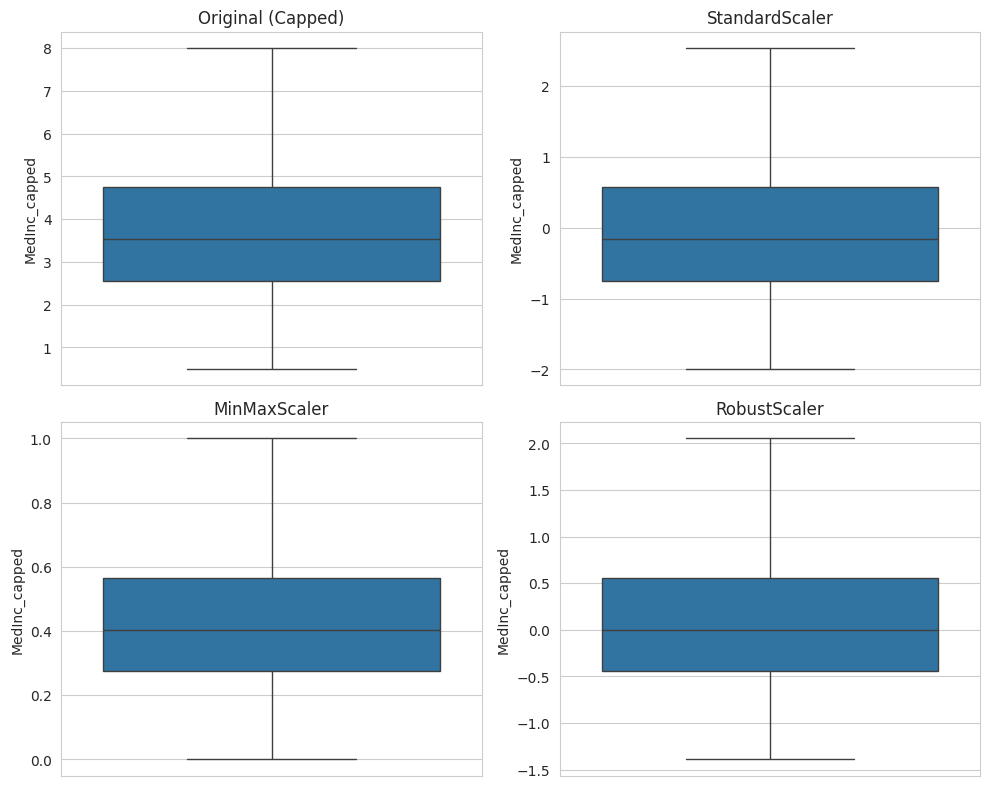

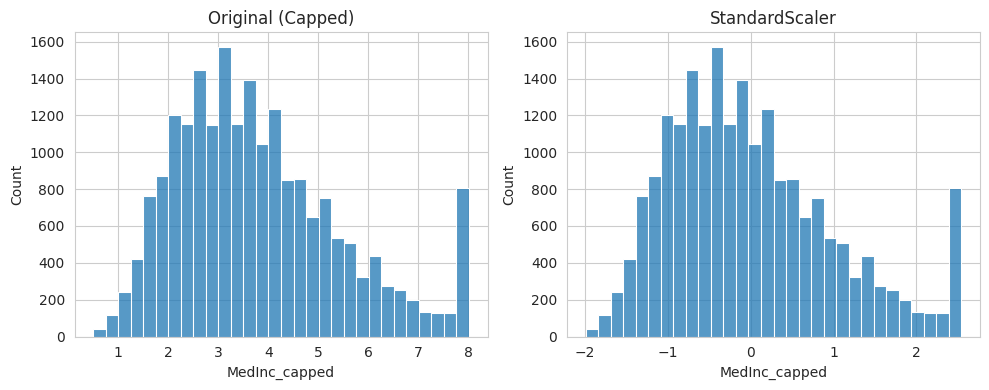

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(10,8))
sns.boxplot(y=X["MedInc_capped"],ax=ax[0,0]); ax[0,0].set_title("Original (Capped)")
sns.boxplot(y=X_standard["MedInc_capped"],ax=ax[0,1]); ax[0,1].set_title("StandardScaler")
sns.boxplot(y=X_minmax["MedInc_capped"],ax=ax[1,0]); ax[1,0].set_title("MinMaxScaler")
sns.boxplot(y=X_robust["MedInc_capped"],ax=ax[1,1]); ax[1,1].set_title("RobustScaler")
plt.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.histplot(X["MedInc_capped"],bins=30,ax=ax[0]); ax[0].set_title("Original (Capped)")
sns.histplot(X_standard["MedInc_capped"],bins=30,ax=ax[1]); ax[1].set_title("StandardScaler")
plt.tight_layout()

### Observation Questions
- Which scaler limits values to [0,1]?
- Which scaler is least affected by outliers?
- Does scaling remove outliers?
- Which scaler would you use when data contains many outliers?

## I. ML Readiness - Train/Test Split

In [ ]:
y=df["MedHouseVal"]

X_train,X_test,y_train,y_test=train_test_split(
    X_standard,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:",X_train.shape)
print("Testing Features:",X_test.shape)
print("Training Labels:",y_train.shape)
print("Testing Labels:",y_test.shape)

X_train.head()

Training Features: (16512, 4)
Testing Features: (4128, 4)
Training Labels: (16512,)
Testing Labels: (4128,)


,MedInc_capped,HouseAge,AveRooms,Population
14196,-0.326619,0.346478,-0.166259,0.772251
8267,0.006932,1.617807,-0.386181,-0.098440
17445,0.214338,-1.957806,0.087641,-0.450778
14265,-1.121193,0.584852,-0.576442,-0.006602
2271,-0.148894,1.141059,0.339282,-0.486983


#Concepts
Train/Test Split: Divide data into training and testing sets.

Stratified Sampling: Maintain class distribution across splits.

Class Imbalance: Occurs when one class has significantly more samples than others.

SMOTE(Synthetic Minority Over-sampling Technique): Generates synthetic samples for minority classes.


## Final Reflection
1. Why should outlier treatment be performed before scaling?
2. Which scaler would you recommend for skewed data with many outliers?
3. Why is train/test splitting performed after preprocessing?
4. Is the dataset now ready for machine learning? Explain your answer.


# Task:
**Build end to end Machine Learning Data Preparation Pipeline using Kaggle NSL-KDD dataset**